In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Movie recomender/Train_v2/ready_to_train_ds.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Columns: 268 entries, overview to original_language_zh
dtypes: bool(37), float64(4), int64(224), object(3)
memory usage: 8.6+ MB


In [14]:
x = df.select_dtypes(include=['number', 'bool'])

In [16]:
x = x.astype({col: 'int' for col in x.select_dtypes('bool').columns})
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Columns: 265 entries, popularity to original_language_zh
dtypes: float64(4), int64(261)
memory usage: 9.7 MB


In [40]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(x)
df['cluster'] = kmeans.labels_
print(df['cluster'].value_counts())
score = silhouette_score(X, kmeans.labels_)
print('sillhouette_score:' , score)

cluster
0    4403
1     400
Name: count, dtype: int64
sillhouette_score: 0.48845435768271384


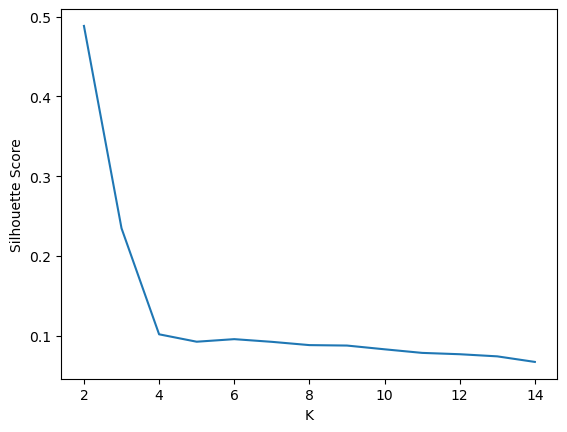

In [41]:
scores = []
K = range(2, 15)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x)
    scores.append(silhouette_score(x, km.labels_))

plt.plot(K, scores)
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

In [42]:
x.head(10)

,popularity,runtime,vote_average,vote_count,Action,Adventure,Animation,Comedy,Crime,Documentary,...,original_language_ru,original_language_sl,original_language_sv,original_language_ta,original_language_te,original_language_th,original_language_tr,original_language_vi,original_language_xx,original_language_zh
0,5.817207,2.468085,0.833333,17.047198,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.336857,2.765957,0.583333,6.280236,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.995603,1.872340,0.083333,6.230088,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,4.204418,2.595745,1.166667,13.073746,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1.311482,1.191489,-0.083333,2.775811,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4.347693,1.489362,-0.250000,4.917404,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1.512632,-0.170213,1.000000,4.554572,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,5.133659,1.574468,0.916667,9.623894,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,3.636402,2.085106,1.000000,7.449853,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,6.043650,2.000000,-0.416667,9.973451,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
